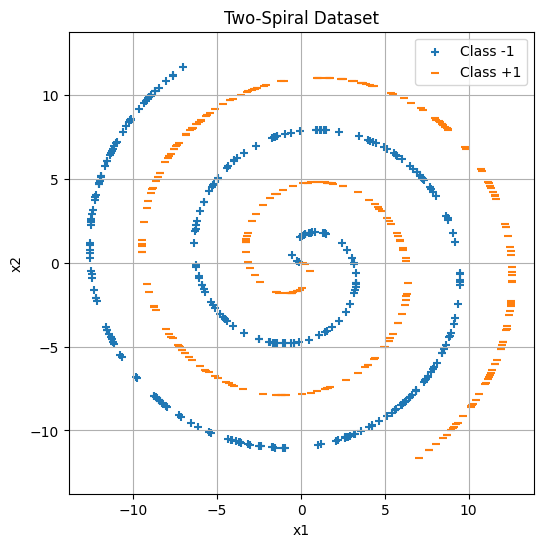

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----- Spiral function from the book DL -----
def twoSpirals(N):
    np.random.seed(1) #This ensures that every time you run the code you get the same spiral

    n = np.sqrt(np.random.rand(N, 1)) * 780 * (2 * np.pi) / 360

    x = -np.cos(n) * n
    y =  np.sin(n) * n

    return (                        #Returns: X, y   --- (x,y) and (-x,-y)
        np.vstack((
            np.hstack((x, y)),
            np.hstack((-x, -y))
        )),
        np.hstack((
            -np.ones(N),
             np.ones(N)
        ))
    )

# Generate data
X, y = twoSpirals(300)

# ----- Plot -----
plt.figure(figsize=(6,6))

# Class -1
plt.scatter(
    X[y == -1, 0],
    X[y == -1, 1],
    marker='+',
    label='Class -1'
)

# Class +1
plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    marker='_',
    label='Class +1'
)

plt.title("Two-Spiral Dataset")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.axis('equal')   # keeps aspect ratio correct
plt.grid(True)
plt.show()

In [ ]:
X[:5]

array([[ 7.08535569,  5.20423916],
       [-6.12292297, -9.79831639],
       [-0.14405156,  0.02112219],
       [-2.69700026,  6.98263954],
       [-2.51308117, -4.56974622]])

In [ ]:
y[:5]

array([-1., -1., -1., -1., -1.])

In [ ]:
np.unique(y)

array([-1.,  1.])

In [ ]:
X.shape

(600, 2)

In [ ]:
import numpy as np

# -----------------------------
# Spiral dataset
# -----------------------------
def twoSpirals(N):
    np.random.seed(1)
    n = np.sqrt(np.random.rand(N, 1)) * 780 * (2*np.pi) / 360
    x = -np.cos(n) * n
    y =  np.sin(n) * n
    return (
        np.vstack((np.hstack((x, y)), np.hstack((-x, -y)))),
        np.hstack((np.ones(N)*-1, np.ones(N)))
    )

# -----------------------------
# Sigmoid
# -----------------------------
def sigmoid(z, grad=False):
    if grad:
        return z * (1. - z)      # assumes z is already sigmoid(z)
    return 1. / (1. + np.exp(-z))

# -----------------------------
# Data
# -----------------------------
N = 300
X, y = twoSpirals(N)          # X: (600,2), y: (600,) in {-1,+1}

# Convert y to 2D targets (e.g., y1 = [1 0])
# First N points are -1  -> [1, 0]
# Second N points are +1 -> [0, 1]
Y = np.zeros((2*N, 2))
Y[y == -1] = [1, 0]
Y[y ==  1] = [0, 1]

# -----------------------------
# Step 1 – Initialization
# -----------------------------
# (optionally set a seed so results are repeatable)
np.random.seed(0)
w1 = 2.0*np.random.random((2, 3)) - 1.0   # W^(1) in R^(2x3)
w2 = 2.0*np.random.random((3, 2)) - 1.0   # W^(2) in R^(3x2)

# Hyperparameters
t = 100000
lambda_ = 0.00001
alpha = 0.001

# -----------------------------
# Training loop
# -----------------------------
for epoch in range(t):

    # Step 2 – Forward pass
    o1 = sigmoid(np.matmul(X, w1))        # o1 = sigmoid(X w1)
    o2 = sigmoid(np.matmul(o1, w2))       # o2 = sigmoid(o1 w2)

    # Step 3 – Loss
    L = np.square(Y - o2).sum()/(2*(2*N)) + lambda_*(np.square(w1).sum() + np.square(w2).sum())/(2*(2*N))

    # Step 4 – Backward pass
    dL_do2 = -(Y - o2)
    do2_dz2 = sigmoid(o2, grad=True)
    dz2_dw2 = o1
    dL_dw2 = dz2_dw2.T.dot(dL_do2 * do2_dz2) + lambda_*np.square(w2).sum()

    dL_dz2 = dL_do2 * do2_dz2
    dz2_do1 = w2
    dL_do1 = dL_dz2.dot(dz2_do1.T)
    do1_dz1 = sigmoid(o1, grad=True)
    dz1_dw1 = X
    dL_dw1 = dz1_dw1.T.dot(dL_do1 * do1_dz1) + lambda_*np.square(w1).sum()

    # Weight update
    w1 += -alpha * dL_dw1
    w2 += -alpha * dL_dw2

    # Print sometimes
    if epoch % 10000 == 0:
        print(f"epoch={epoch:6d}  loss={L:.6f}")

print("\nFinal weights:")
print("w1=\n", w1)
print("w2=\n", w2)

epoch=     0  loss=0.276396
epoch= 10000  loss=0.222386
epoch= 20000  loss=0.222212
epoch= 30000  loss=0.222062
epoch= 40000  loss=0.221939
epoch= 50000  loss=0.221847
epoch= 60000  loss=0.221780
epoch= 70000  loss=0.221731
epoch= 80000  loss=0.221694
epoch= 90000  loss=0.221666

Final weights:
w1=
 [[ 0.11433896 -0.10880808  1.47277458]
 [ 0.11773065 -0.11094912  8.72557736]]
w2=
 [[-2.71840465  2.71837445]
 [ 1.71267368 -1.71270426]
 [ 1.01177749 -1.01177668]]


epoch=     0  loss=0.276396
epoch= 10000  loss=0.222386
epoch= 20000  loss=0.222212
epoch= 30000  loss=0.222062
epoch= 40000  loss=0.221939
epoch= 50000  loss=0.221847
epoch= 60000  loss=0.221780
epoch= 70000  loss=0.221731
epoch= 80000  loss=0.221694
epoch= 90000  loss=0.221666

Final weights:
w1=
 [[ 0.11433896 -0.10880808  1.47277458]
 [ 0.11773065 -0.11094912  8.72557736]]
w2=
 [[-2.71840465  2.71837445]
 [ 1.71267368 -1.71270426]
 [ 1.01177749 -1.01177668]]


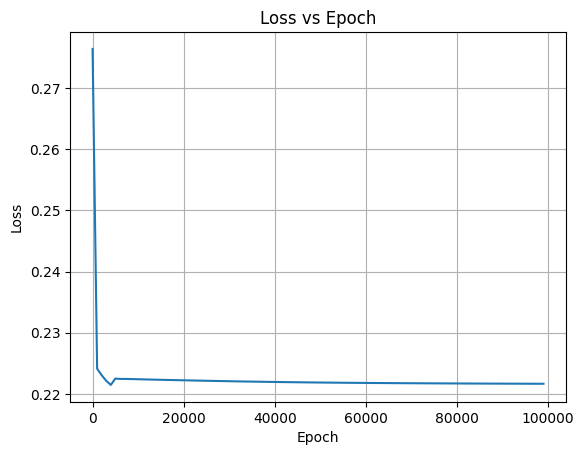

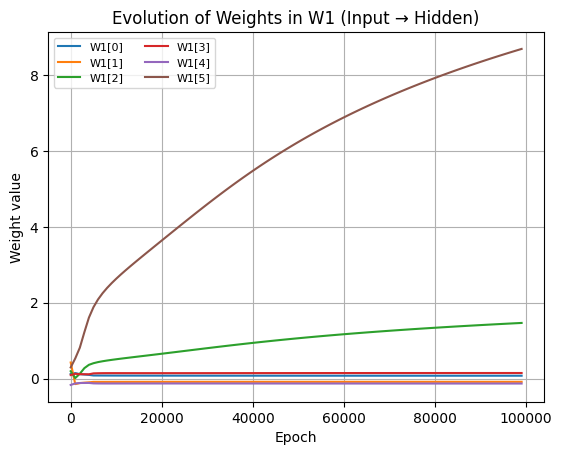

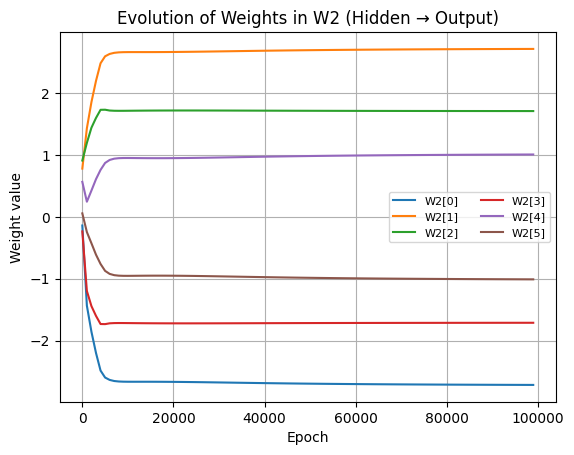

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Spiral dataset
# -----------------------------
def twoSpirals(N):
    np.random.seed(1)
    n = np.sqrt(np.random.rand(N, 1)) * 780 * (2*np.pi) / 360
    x = -np.cos(n) * n
    y =  np.sin(n) * n
    return (
        np.vstack((np.hstack((x, y)), np.hstack((-x, -y)))),
        np.hstack((np.ones(N)*-1, np.ones(N)))
    )

# -----------------------------
# Sigmoid
# -----------------------------
def sigmoid(z, grad=False):
    if grad:
        return z * (1. - z)  # assumes z is already sigmoid(z)
    return 1. / (1. + np.exp(-z))

# -----------------------------
# Data
# -----------------------------
N = 300
X, y = twoSpirals(N)  # X: (600,2), y: (600,) in {-1,+1}

# Convert y to 2D targets  (e.g., y1 = [1 0])
Y = np.zeros((2*N, 2))
Y[y == -1] = [1, 0]
Y[y ==  1] = [0, 1]

# -----------------------------
# Step 1 – Initialization
# -----------------------------
np.random.seed(0)
w1 = 2.0*np.random.random((2, 3)) - 1.0   # W^(1) in R^(2x3)
w2 = 2.0*np.random.random((3, 2)) - 1.0   # W^(2) in R^(3x2)

# Hyperparameters
t = 100000
lambda_ = 0.00001 #penalty
alpha = 0.001 #learning rate

# -----------------------------
# Tracking (for plotting)
# -----------------------------
record_every = 1000  # record every 1000 epochs (100 points total if t=100000)
epochs_rec = []   # record the epoch numbers when recording the losses
loss_hist = []
w1_hist = []   # each entry is w1 flattened (6 numbers)
w2_hist = []   # each entry is w2 flattened (6 numbers)

# -----------------------------
# Training loop
# -----------------------------
for epoch in range(t):

    # Step 2 – Forward pass
    o1 = sigmoid(np.matmul(X, w1))        # o1 = sigmoid(X w1)
    o2 = sigmoid(np.matmul(o1, w2))       # o2 = sigmoid(o1 w2)

    # Step 3 – Loss
    L = np.square(Y - o2).sum()/(2*(2*N)) + lambda_*(np.square(w1).sum() + np.square(w2).sum())/(2*(2*N))

    # Step 4 – Backward pass
    dL_do2 = -(Y - o2)
    do2_dz2 = sigmoid(o2, grad=True)
    dz2_dw2 = o1
    dL_dw2 = dz2_dw2.T.dot(dL_do2 * do2_dz2) + lambda_*np.square(w2).sum()

    dL_dz2 = dL_do2 * do2_dz2
    dz2_do1 = w2
    dL_do1 = dL_dz2.dot(dz2_do1.T)
    do1_dz1 = sigmoid(o1, grad=True)
    dz1_dw1 = X
    dL_dw1 = dz1_dw1.T.dot(dL_do1 * do1_dz1) + lambda_*np.square(w1).sum()

    # Weight update
    w1 += -alpha * dL_dw1
    w2 += -alpha * dL_dw2

    # Print sometimes
    if epoch % 10000 == 0:
        print(f"epoch={epoch:6d}  loss={L:.6f}")

    # Record for plots
    if epoch % record_every == 0:
        epochs_rec.append(epoch)
        loss_hist.append(L)
        w1_hist.append(w1.flatten().copy())
        w2_hist.append(w2.flatten().copy())

# -----------------------------
# Final weights
# -----------------------------
print("\nFinal weights:")
print("w1=\n", w1)
print("w2=\n", w2)

# -----------------------------
# Plot: Loss evolution
# -----------------------------
plt.figure()
plt.plot(epochs_rec, loss_hist)
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# -----------------------------
# Plot: Weight evolution (W1)
# -----------------------------
w1_hist = np.array(w1_hist)  # shape: (Trec, 6)
plt.figure()
for i in range(w1_hist.shape[1]):
    plt.plot(epochs_rec, w1_hist[:, i], label=f"W1[{i}]")
plt.title("Evolution of Weights in W1 (Input → Hidden)")
plt.xlabel("Epoch")
plt.ylabel("Weight value")
plt.grid(True)
plt.legend(ncol=2, fontsize=8)
plt.show()

# -----------------------------
# Plot: Weight evolution (W2)
# -----------------------------
w2_hist = np.array(w2_hist)  # shape: (Trec, 6)
plt.figure()
for i in range(w2_hist.shape[1]):
    plt.plot(epochs_rec, w2_hist[:, i], label=f"W2[{i}]")
plt.title("Evolution of Weights in W2 (Hidden → Output)")
plt.xlabel("Epoch")
plt.ylabel("Weight value")
plt.grid(True)
plt.legend(ncol=2, fontsize=8)
plt.show()

Google Colab already comes with:

 TensorFlow installed

 Keras included inside TensorFlow

# Batch size:

The number of training samples used before updating the weights once.
batch_size = 60




The model takes 60 samples

Does forward pass

Computes loss

Does backward pass

Updates weights

That is one weight update step.

# Dense means:

A fully connected layer.

Epoch 1/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4990 - loss: 0.3119  
Epoch 2/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4865 - loss: 0.3218 
Epoch 3/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4797 - loss: 0.3199 
Epoch 4/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5288 - loss: 0.3031 
Epoch 5/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4805 - loss: 0.3177 
Epoch 6/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4569 - loss: 0.3155 
Epoch 7/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4071 - loss: 0.3215
Epoch 8/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4553 - loss: 0.3093 
Epoch 9/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4570 - loss: 0.3127
Epoch 10/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4198 - loss: 0.3139 
Epoch 11/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4334 - loss: 0.3053  
Epoch 12/1000
10/10 ━━━━━━━━━━━━━━━━━━

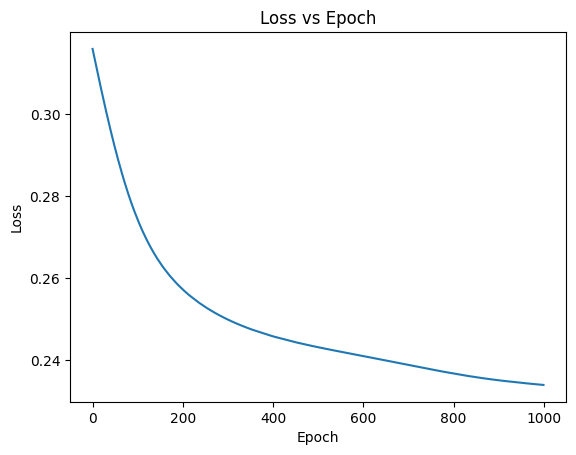

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# -----------------------------
# Spiral dataset
# -----------------------------
def twoSpirals(N):
    np.random.seed(1)
    n = np.sqrt(np.random.rand(N, 1)) * 780 * (2*np.pi) / 360
    x = -np.cos(n) * n
    y =  np.sin(n) * n
    return (
        np.vstack((np.hstack((x, y)), np.hstack((-x, -y)))),
        np.hstack((np.ones(N)*-1, np.ones(N)))
    )

# -----------------------------
# Generate data
# -----------------------------
X, y = twoSpirals(300)

# Convert {-1,+1} to {0,1}
y_binary = (y == 1).astype(int)

# Convert to one-hot encoding (needed for 2 output neurons)
y_cat = to_categorical(y_binary)

# -----------------------------
# Build MLP
# -----------------------------
mlp = Sequential()
mlp.add(Dense(3, input_dim=2, activation='sigmoid'))
mlp.add(Dense(2, activation='sigmoid'))

mlp.compile(
    loss='mean_squared_error',
    optimizer='sgd',
    metrics=['accuracy']
)

# -----------------------------
# Train
# -----------------------------
history = mlp.fit(
    X, y_cat,
    epochs=1000,
    batch_size=60,
    verbose=1
)

# -----------------------------
# Plot loss
# -----------------------------
plt.plot(history.history['loss'])
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()